# Simulations light inter

In [1]:
from __future__ import annotations

import math
import os
import sys
import time as t
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

sys.path.append(".") 
from plot_outputs import *

sys.path.append("../data") 
from archi_dict import archi_sorghum_angles as archi
# from oawidgets.plantgl import *  # noqa: F403

from openalea.archicrop.display import build_scene, display_scene  # noqa: F401
from openalea.archicrop.simulation import compute_extinction_coef, concat_ds
from openalea.plantgl.all import Color3, Material, Scene  # noqa: F401


%gui qt

In [2]:
stics_color = "orange"
archicrop_color = "green"

In [3]:
tec_file_xml='../data/02NT18SorgV2D1_tec.xml'
plt_file_xml='../data/plant/sorgho_imp_M_v10_plt.xml'
stics_output_file='../data/mod_s02NT18SorgV2D1.sti'
weather_file = '../data/ntarla_corr.2018'
location = {  
'longitude': 3.87,
'latitude': 12.58,
'altitude': 800,
'timezone': 'Europe/Paris'}

In [4]:
seed = 18

In [5]:
def open_ds(day_str,n_cpu):
    file_list = []
    for cpu in range(n_cpu):
        file_list.append(f"D:/PhD_Oriane/simulations_ArchiCrop/{day_str}/results_light_inter_{cpu}.nc")
    ds = concat_ds(file_list)
    return ds


In [6]:
day_str = "2026-02-10"
n_cpu = 9
ds = open_ds(day_str,n_cpu)
ds

D:\ArchiCrop\src\openalea\archicrop\simulation.py:408: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'leaf' ('leaf',) The recommendation is to set join explicitly for this case.
  ds_tot = xr.concat([ds_tot, ds_new], dim="id")
D:\ArchiCrop\src\openalea\archicrop\simulation.py:408: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_tot = xr.concat([ds_tot, ds_new], dim="id")
D:\ArchiCrop\src\openalea\archicrop\simu

<xarray.Dataset> Size: 2MB
Dimensions:                 (id: 45, time: 119, leaf: 28)
Coordinates:
  * id                      (id) int32 180B 1 2 3 4 5 13 ... 237 238 239 240 241
  * time                    (time) datetime64[ns] 952B 2018-06-30 ... 2018-10-26
  * leaf                    (leaf) int32 112B 1 2 3 4 5 6 ... 23 24 25 26 27 28
Data variables: (12/42)
    thermal_time            (id, time) float64 43kB 16.81 28.0 ... 1.706e+03
    lai_stics               (id, time) float64 43kB 0.037 0.1111 ... 3.597e+03
    sen_lai_stics           (id, time) float64 43kB 0.0 0.0 ... 2.246e+03
    height_stics            (id, time) float64 43kB 0.003 0.008 ... 148.7 148.7
    inc_par                 (id, time) float64 43kB 9.622 5.153 ... 9.074 9.302
    abs_par_stics           (id, time) float64 43kB 0.0 0.0 ... 0.4663 0.4
    ...                      ...
    leaf_lifespan           (id) float64 360B 280.0 280.0 280.0 ... 280.0 280.0
    leaf_lifespan_early     (id) float64 360B 224.0 224.0 224.0 ... 224.0 224.0
    nb_phy                  (id) int32 180B 12 12 12 12 12 12 ... 28 28 28 28 28
    insertion_angle         (id) int32 180B 10 20 30 40 50 60 ... 50 60 70 80 90
    density                 (id) float64 360B 5.4 5.4 5.4 5.4 ... 5.4 5.4 5.4
    inter_row               (id) float64 360B 0.4 0.4 0.4 0.4 ... 0.4 0.4 0.4

In [7]:
dates = ds.time.values
dates = pd.to_datetime(dates)
dates = dates.strftime('%Y-%m-%d')
thermal_time = ds.thermal_time.values[0]
leaf_area_plant = ds.lai_stics.values[0]
sen_leaf_area_plant = ds.sen_lai_stics.values[0]
height_canopy = ds.height_stics.values[0]
par_incident = ds.inc_par.values[0]
par_stics = ds.abs_par_stics.values[0]
density = ds.density.values[0]

phyllotactic_angle = ds.phyllotactic_angle.values
insertion_angle = dict(zip(ds.id.values, ds.insertion_angle.values))
curvature = dict(zip(ds.id.values, ds.curvature.values))
nb_phy = dict(zip(ds.id.values, ds.nb_phy.values))

pot_la = dict(zip(ds.id.values, ds.pot_la.values))
pot_h = dict(zip(ds.id.values, ds.pot_h.values))
realized_la = dict(zip(ds.id.values, ds.realized_la.values))
realized_h = dict(zip(ds.id.values, ds.realized_h.values))
nrj_leaf = dict(zip(ds.id.values, ds.nrj_leaf.values))


In [8]:
insertion_angle = {id:i for id,i in insertion_angle.items()}
curvature = {id:i for id,i in curvature.items()}
nb_phy = {id:i for id,i in nb_phy.items()}
# for id,nrj in nrj_leaf.items():
#     for i,t in enumerate(nrj):
#         for j,leaf in enumerate(t):
#             if leaf == 0.0 or math.isnan(leaf):
#                 print(nrj_leaf[id][i])
#                 nrj_leaf[id][i] = t[:j]
#                 break

nrj_crop = {id:[np.nansum([leaf for i,leaf in enumerate(t) if i < nb_phy[id]])*density for t in nrj] for id,nrj in nrj_leaf.items()}

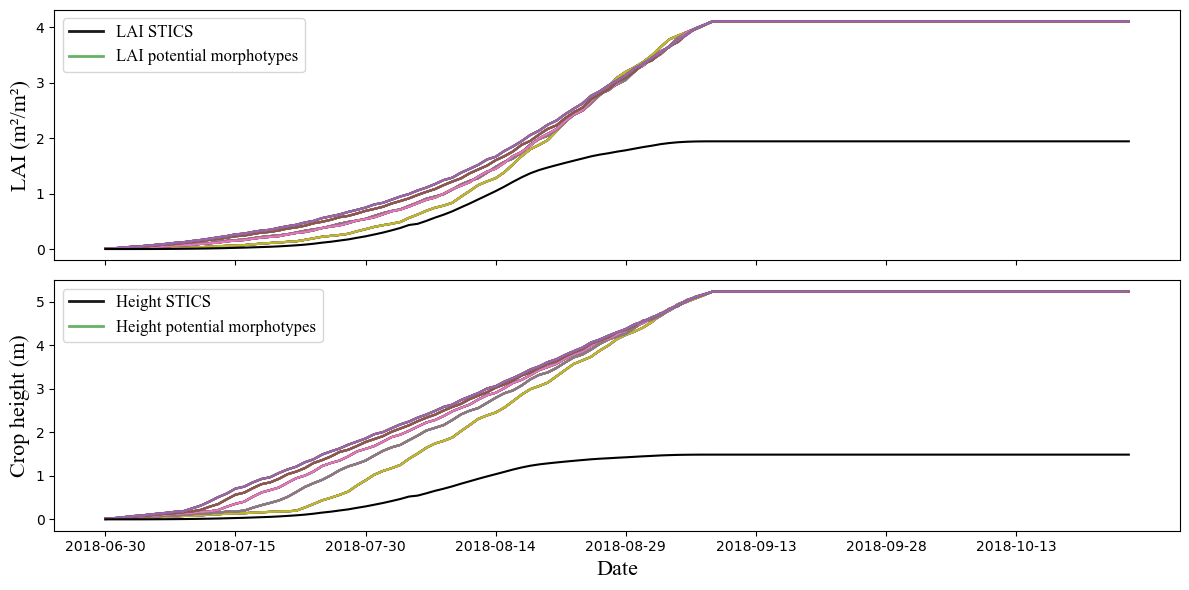

In [9]:
plot_constained_vs_pot(dates, pot_la, pot_h, leaf_area_plant, height_canopy, density, stics_color="black")

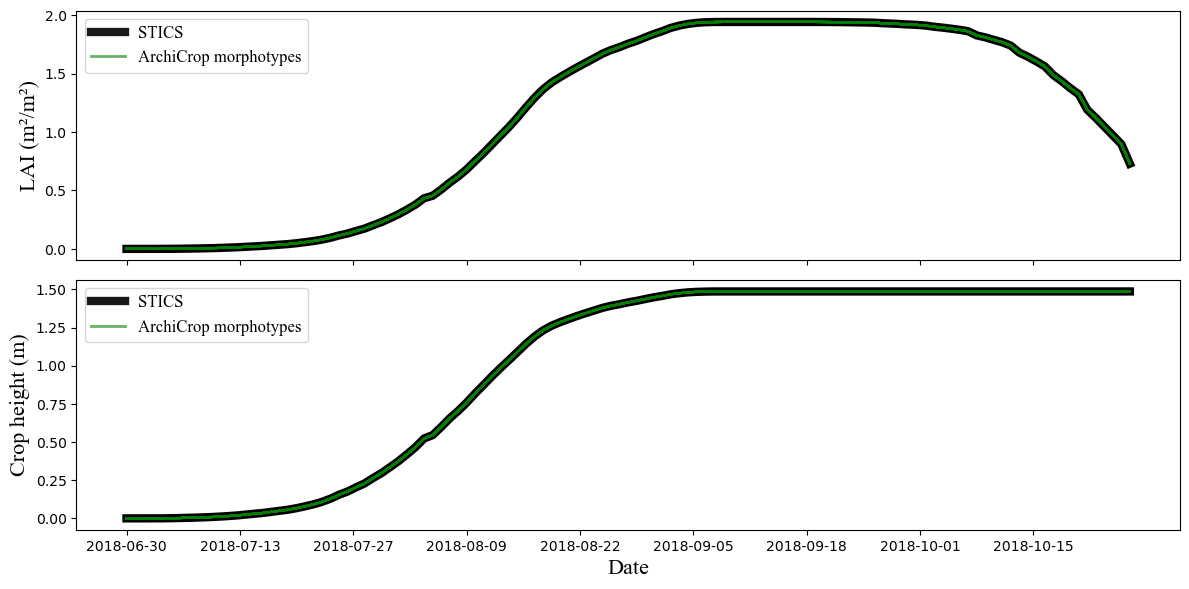

In [10]:
plot_constrainted_vs_realized(dates=dates, 
                              LA_archicrop=realized_la, 
                              height_archicrop=realized_h, 
                              leaf_area_plant=leaf_area_plant, 
                              sen_leaf_area_plant=sen_leaf_area_plant, 
                              height_canopy=height_canopy, 
                              density=density,
                              stics_color="black")


In [11]:
# Energy in Caribu : MJ.day-1
# Irradiance in Caribu : MJ.m[leaf]-2.day-1
# Incident PAR in STICS : MJ.m[soil]-2.day-1
# Absorbed PAR in STICS : MJ.m[soil]-2.day-1

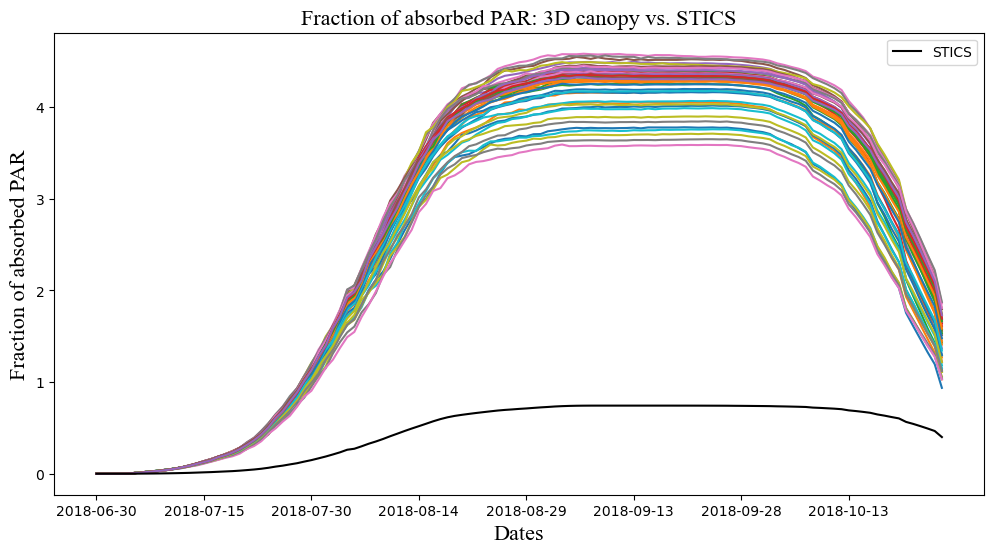

In [12]:
plot_faPAR(dates, nrj_crop, par_incident, par_stics, density, stics_color="black")

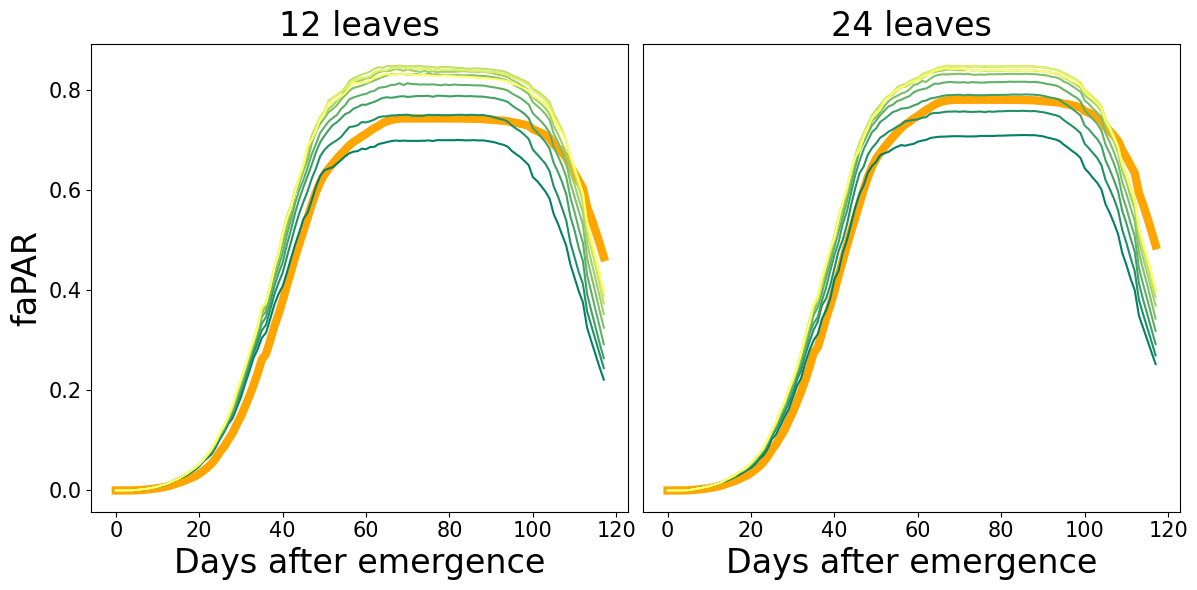

In [13]:
plot_faPAR_parameter(dates, nrj_crop, par_incident, par_stics, density, archi, nb_phy, insertion_angle, 'insertion_angle', archicrop_color, stics_color='orange')

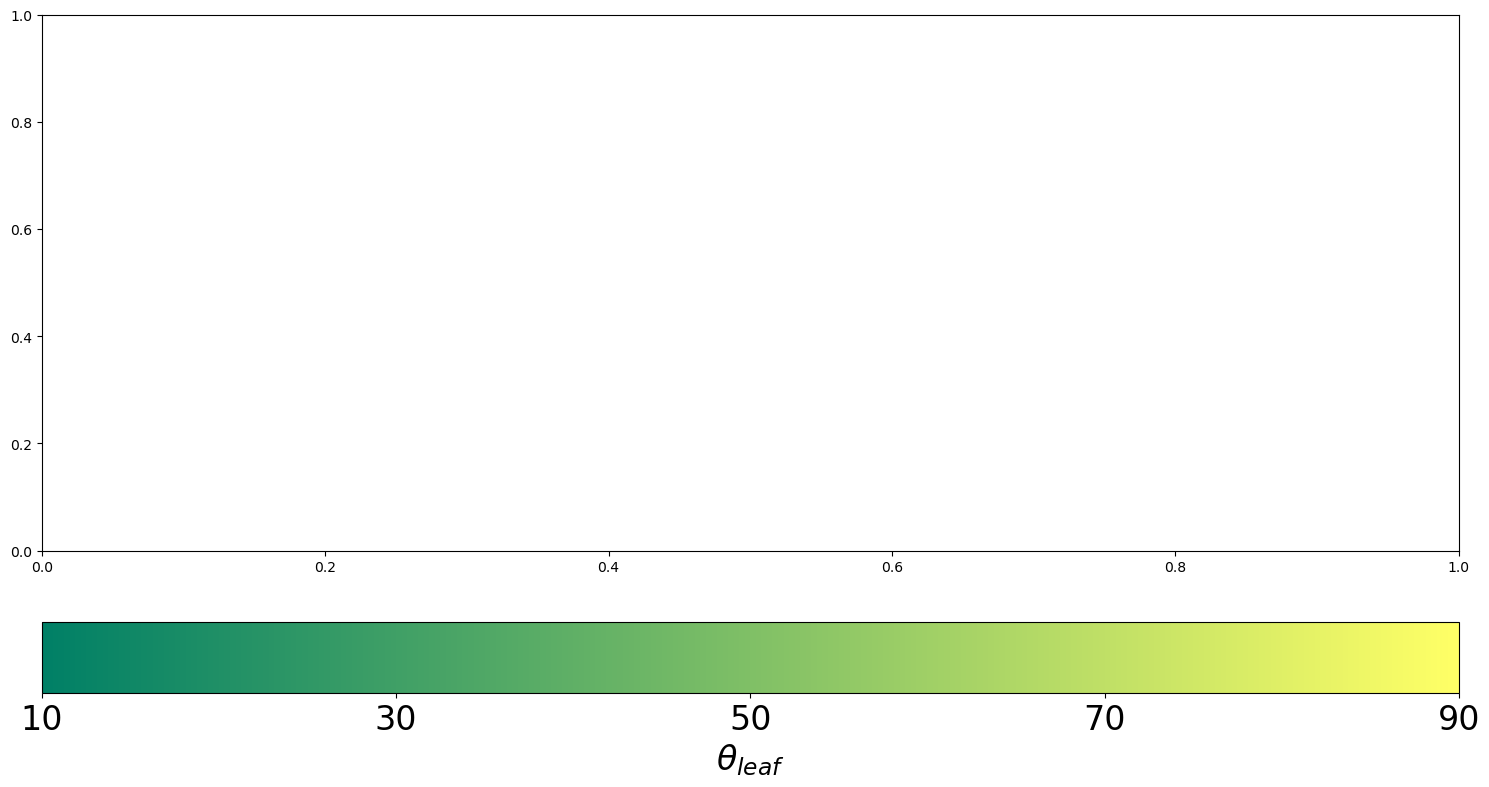

In [14]:
# Add colorbar legend
fig, ax = plt.subplots(1,1,figsize=(15, 8))
param_values = np.array([insertion_angle[k] for k in nrj_crop])
norm = plt.Normalize(param_values.min(), param_values.max())
cmap = plt.get_cmap('summer')  # You can choose any matplotlib colormap
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.1)
cbar.set_label(r"$\theta_{leaf}$", fontsize=24)
# cbar.set_ticks([param_values.min(), param_values.max()])
cbar.set_ticks([10,30,50,70,90])
cbar.set_ticklabels([10,30,50,70,90], fontsize=24)

plt.tight_layout()

# Save figure
today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True)  # noqa: PTH103
plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/colorbar.png", dpi=1000)


D:\ArchiCrop\tutorials\plot_outputs.py:189: RuntimeWarning: divide by zero encountered in scalar divide
  d.append((par_stics[i] - faPAR) / par_stics[i])
D:\ArchiCrop\tutorials\plot_outputs.py:190: RuntimeWarning: divide by zero encountered in scalar divide
  amp = (max(faPAR_values) - min(faPAR_values)) / par_stics[i]


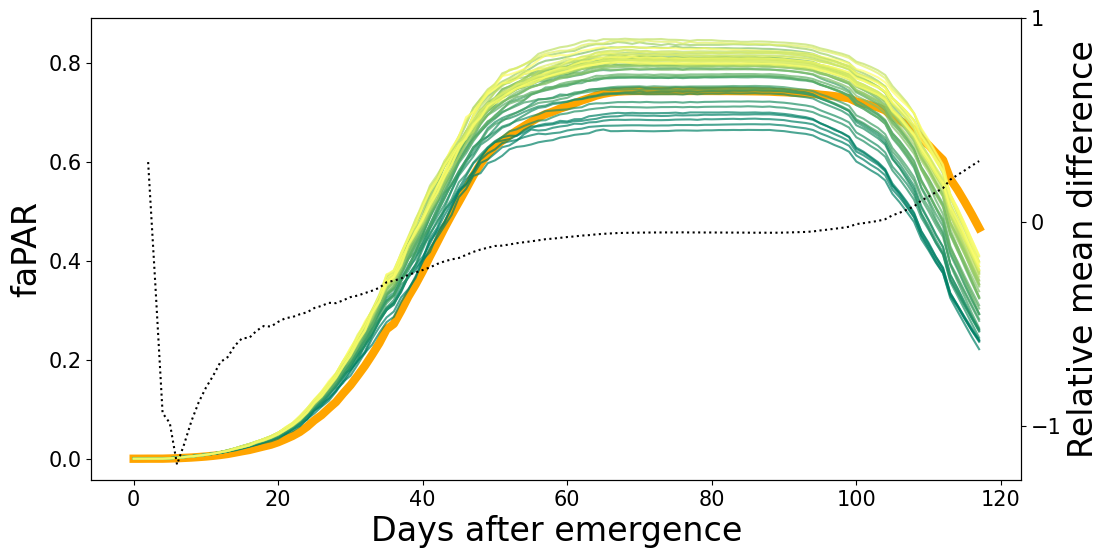

In [15]:
plot_faPAR_variance(dates, nrj_crop, par_incident, par_stics, insertion_angle, 'insertion_angle', archicrop_color, stics_color='orange')

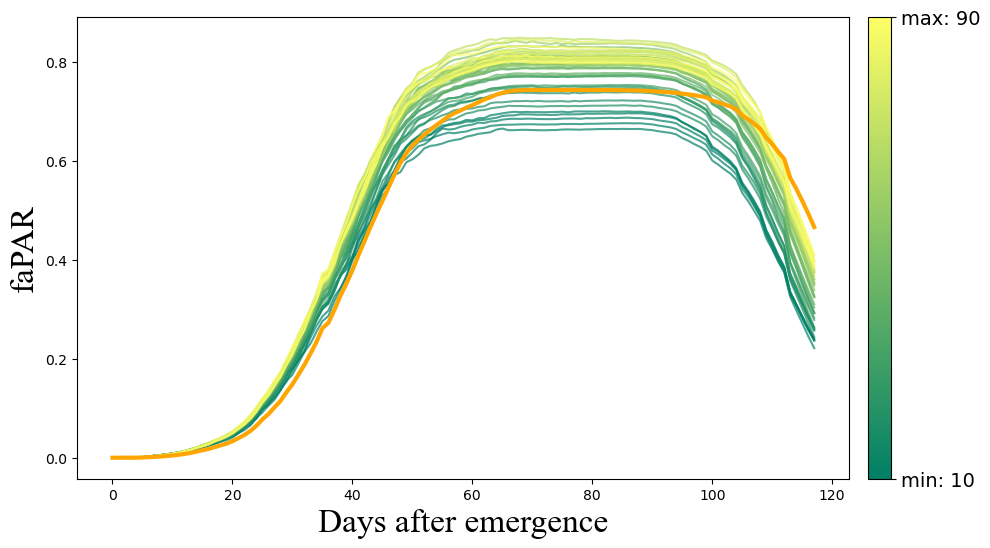

In [16]:
plot_faPAR_parameter_only_archicrop(dates, nrj_crop, par_incident, par_stics, density, archi, insertion_angle, 'insertion_angle', archicrop_color, stics_color='orange')

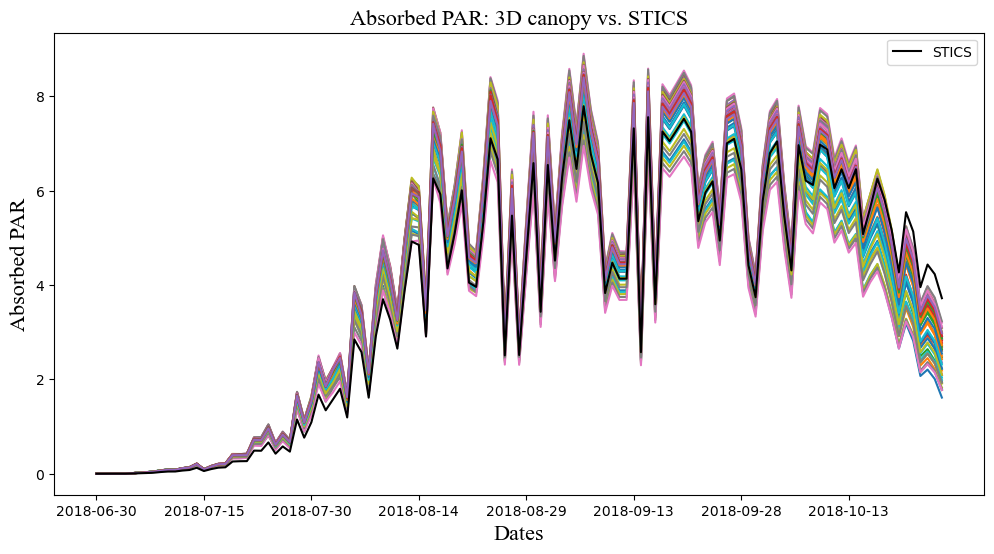

In [17]:
plot_PAR(dates, nrj_crop, par_incident, par_stics, density, stics_color="black")

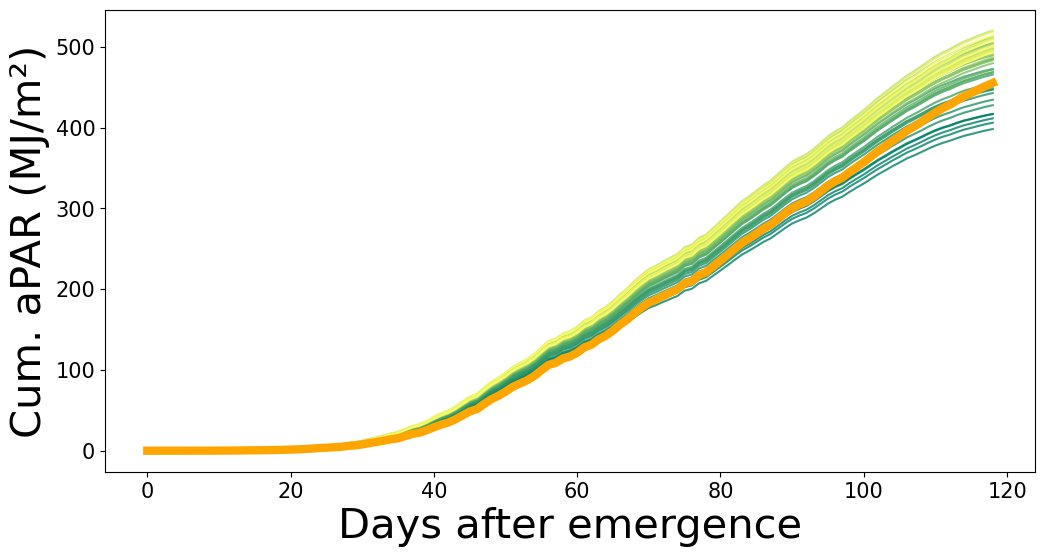

In [18]:
cumsum_nrj_per_plant(dates, nrj_crop, par_incident, par_stics, insertion_angle, 'insertion_angle', archicrop_color, stics_color='orange')

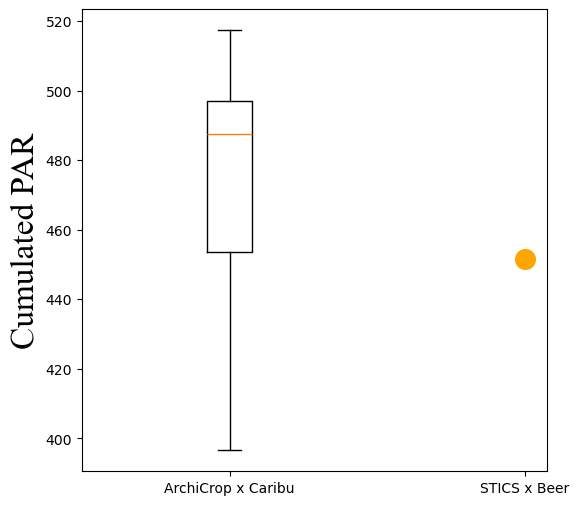

In [19]:
sum_nrj_per_plant(dates, nrj_crop, par_incident, par_stics, insertion_angle, 'insertion_angle', archicrop_color, stics_color='orange')

In [20]:
cf_cm = 100
lai = [la *density/cf_cm**2 for la in leaf_area_plant]

# plot_faPAR_per_leaf_parameter(lai, nrj_leaf, par_incident, par_stics, insertion_angle, 'insertion_angle', archicrop_color, stics_color='orange')

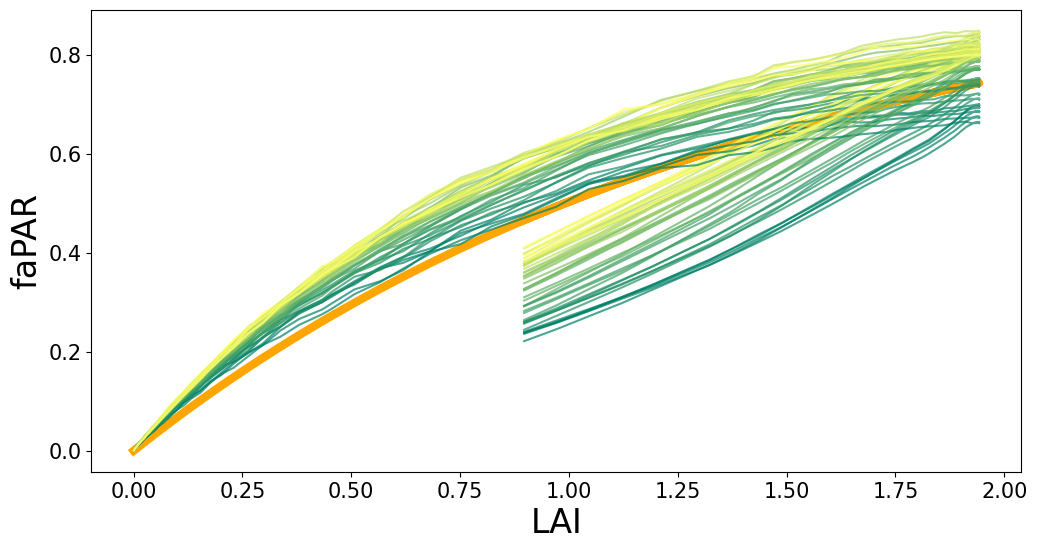

In [21]:
lai = [(la-sen)*density/cf_cm**2 for la, sen in zip(leaf_area_plant, sen_leaf_area_plant)]
plot_faPAR_lai_parameter(lai, nrj_crop, par_incident, par_stics, density, archi, insertion_angle, 'insertion_angle', archicrop_color, stics_color='orange')

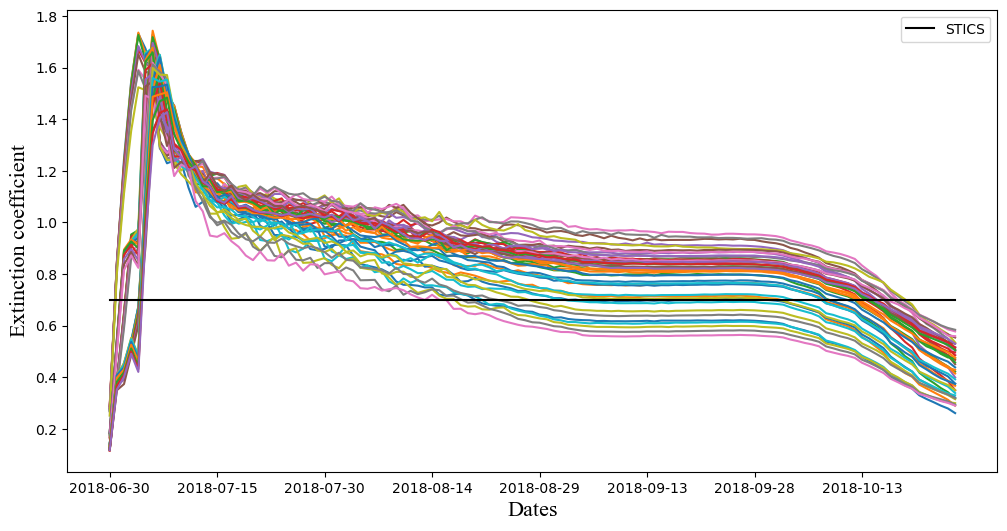

In [22]:
extinP_sorghum = 0.7

lai = [(la-sen)*density/cf_cm**2 for la, sen in zip(leaf_area_plant, sen_leaf_area_plant)]
extin_coefs = compute_extinction_coef(nrj_crop, par_incident, lai)
plot_extinction_coef(extinP_stics=extinP_sorghum, extin_coefs=extin_coefs, dates=dates)

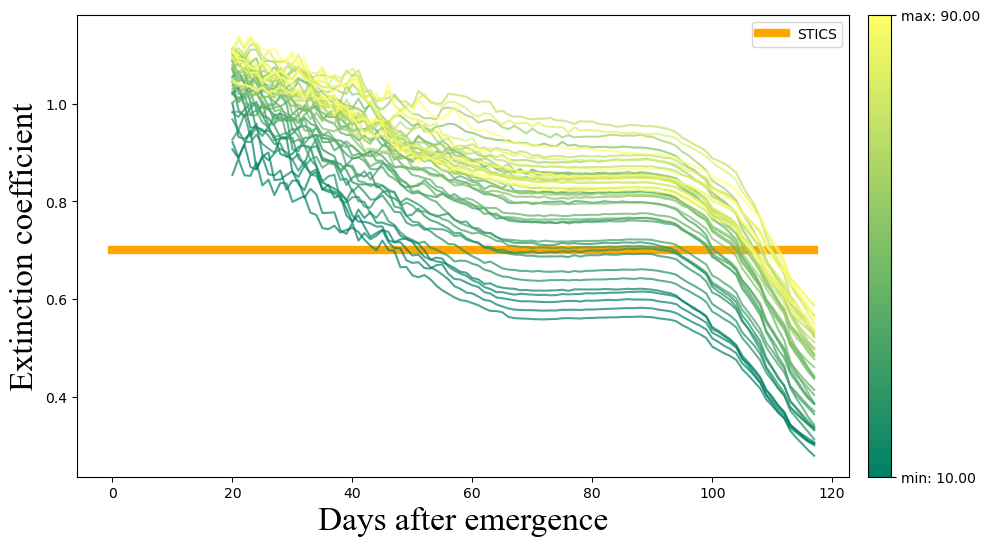

In [23]:
plot_extinction_coef_dyn_parameter(extinP_sorghum, extin_coefs, dates, nrj_crop, archi, insertion_angle, 'insertion_angle', archicrop_color, stics_color=stics_color)

k = -0.000059 theta^2 + 0.0090 theta + 0.55
R2 =  0.9036311345602013


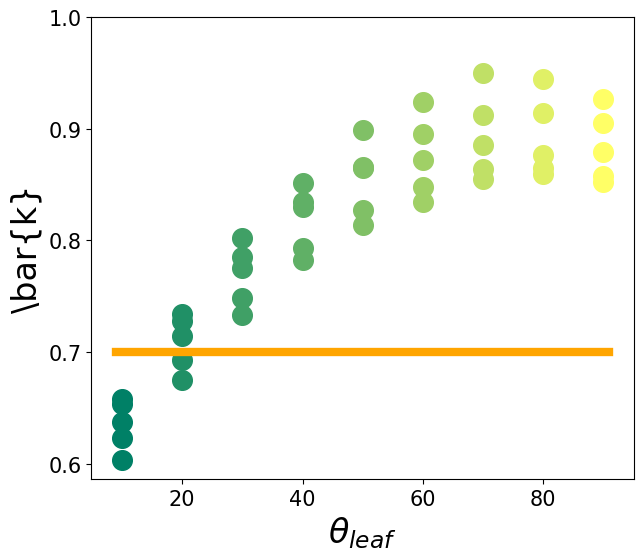

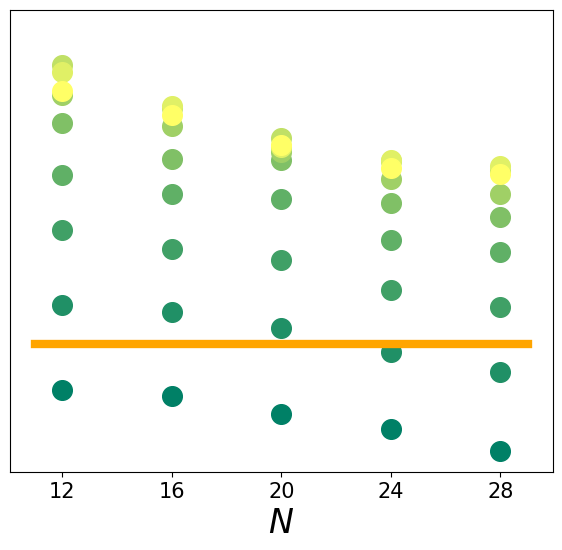

In [24]:
plot_extinction_coef_parameter(extinP_sorghum, extin_coefs, dates, nrj_crop, archi, insertion_angle, 'insertion_angle', insertion_angle, archicrop_color, stics_color=stics_color)
plot_extinction_coef_parameter(extinP_sorghum, extin_coefs, dates, nrj_crop, archi, nb_phy, 'nb_phy', insertion_angle, archicrop_color, stics_color=stics_color)

k = 0.5555 + 0.1263*log(theta) + -0.1205*LAIgreen + -0.9696*pLAIsen
R2 =  0.9384057705963413


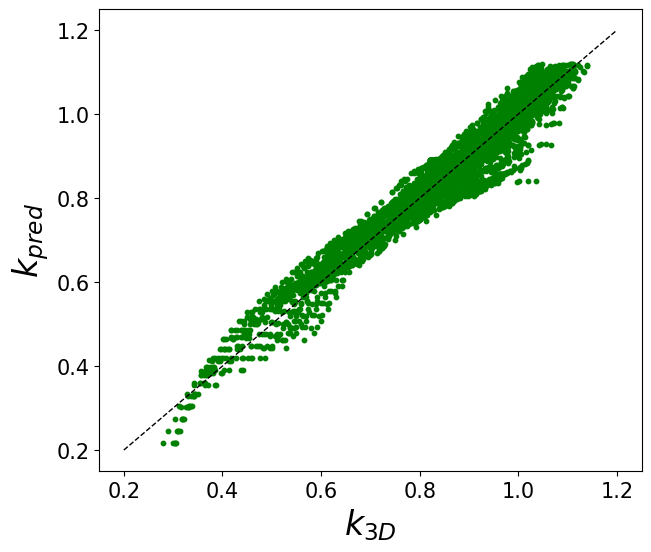

In [25]:
from sklearn.feature_selection import f_regression

start = 20
end = -1

L1 = len(extin_coefs.values())
lai_tot = np.array([la*density/cf_cm**2 for la in leaf_area_plant[start:end]]*L1)
lai_green = np.array([(la-sen)*density/cf_cm**2 for la, sen in zip(leaf_area_plant[start:end], sen_leaf_area_plant[start:end])]*L1)
# percent_green = np.array([green/tot for tot, green in zip(lai_tot, lai_green)])
percent_sen = np.array([1-green/tot for tot, green in zip(lai_tot, lai_green)])
L2 = len(leaf_area_plant[start:end])
theta = np.array(list(insertion_angle.values())).repeat(L2)
theta_log = np.array([math.log(x) for x in insertion_angle.values()]).repeat(L2)
nb = np.array(list(nb_phy.values())).repeat(L2)
k = np.array([ec[start:end] for ec in list(extin_coefs.values())]).flatten() # 2D array 

# print(len(theta_log), len(nb), len(lai_green), len(percent_green))

# X = np.column_stack((theta_log, nb, lai_green, percent_green))
X = np.column_stack((theta_log, lai_green, percent_sen))
# X = np.column_stack((theta_log, lai_green))
model = LinearRegression(fit_intercept=True).fit(X, k)
# model = f_regression(X, y)

# equation = f"k = {model.intercept_:.4f} + {model.coef_[0]:.4f}*log(theta) + {model.coef_[1]:.4f}*N + {model.coef_[2]:.4f}*LAIgreen + {model.coef_[3]:.4f}*pLAIgreen"
equation = f"k = {model.intercept_:.4f} + {model.coef_[0]:.4f}*log(theta) + {model.coef_[1]:.4f}*LAIgreen + {model.coef_[2]:.4f}*pLAIsen"
# equation = f"k = {model.intercept_:.4f} + {model.coef_[0]:.4f}*log(theta) + {model.coef_[1]:.4f}*LAIgreen"
print(equation)

fit_line = model.predict(X)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(k, fit_line, color="green", s=10)
ax.plot([0.2,1.2],[0.2,1.2], linestyle='dashed', color='black', linewidth=1)
ax.set_xlabel(r"$k_{3D}$", fontsize=24)
ax.set_ylabel(r"$k_{pred}$", fontsize=24)
ax.tick_params(axis='both', labelsize=15)

r2 = r2_score(k, fit_line)
# r2 = model.score()
print("R2 = ", r2)

# Save figure
today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True)  # noqa: PTH103
plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/plot_linear_model.png", dpi=1000)

# Export and reimport table with data

k = 0.5554520479250378 + 0.1263*log(theta) + -0.1205*LAIgreen + -0.9696*LAIgreen*pLAIsen
R2 =  0.9384057705963413


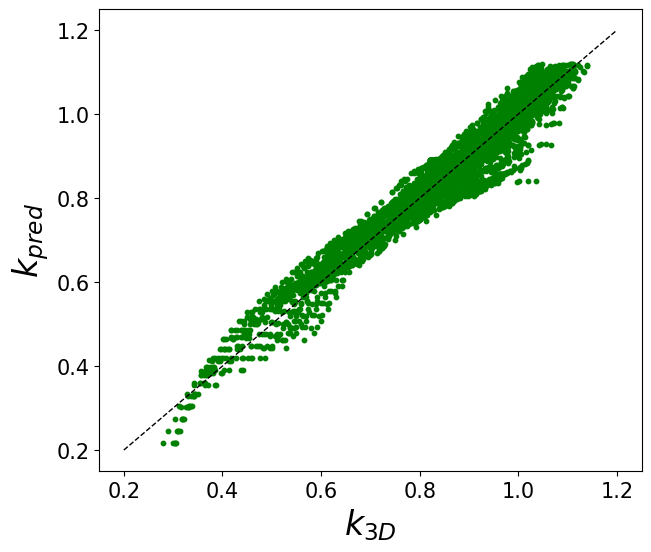

In [26]:
# theta = X[:,0]
theta_log = np.array([math.log(x) for x in theta])
L = X[:,1]
p = X[:,2]

# z = (L != 0).astype(float)  # conditional intercept
# X_model = np.column_stack([
#     z,
#     theta,
#     L,
#     p
# ])

# interaction = L * p

X_model = np.column_stack([
    theta_log,
    L,
    p,
    # interaction
])

model = LinearRegression(fit_intercept=True)
model.fit(X_model, k)

x0, x1, x2 = model.coef_

equation = f"k = {model.intercept_} + {x0:.4f}*log(theta) + {x1:.4f}*LAIgreen + {x2:.4f}*LAIgreen*pLAIsen"
# equation = f"k = {model.intercept_} + {x0:.4f}*log(theta) + {x1:.4f}*LAIgreen"
print(equation)

fit_line = model.predict(X_model)

r2 = r2_score(k, fit_line)
print("R2 = ", r2)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(k, fit_line, color="green", s=10)
ax.plot([0.2,1.2],[0.2,1.2], linestyle='dashed', color='black', linewidth=1)
ax.set_xlabel(r"$k_{3D}$", fontsize=24)
ax.set_ylabel(r"$k_{pred}$", fontsize=24)
ax.tick_params(axis='both', labelsize=15)

Text(0, 0.5, '$k_{pred}$')

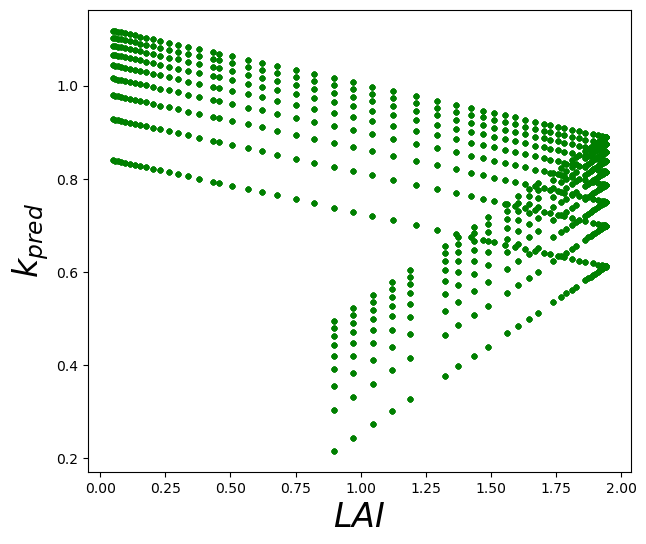

In [27]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(L, fit_line, color="green", s=10)
# ax.plot([0.2,1.2],[0.2,1.2], linestyle='dashed', color='black', linewidth=1)
ax.set_xlabel(r"$LAI$", fontsize=24)
ax.set_ylabel(r"$k_{pred}$", fontsize=24)

Text(0, 0.5, '$k_{pred}$')

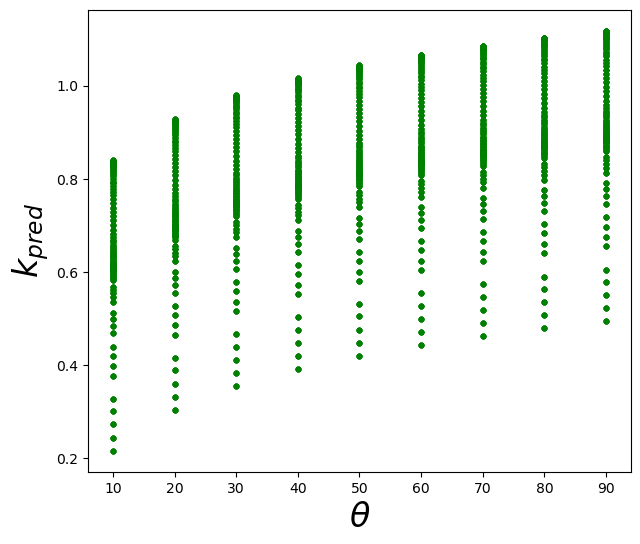

In [28]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(theta, fit_line, color="green", s=10)
# ax.plot([0.2,1.2],[0.2,1.2], linestyle='dashed', color='black', linewidth=1)
ax.set_xlabel(r"$\theta$", fontsize=24)
ax.set_ylabel(r"$k_{pred}$", fontsize=24)

In [29]:
from sklearn.feature_selection import f_regression

f, p = f_regression(X, k)

print(f)
print(p)

[1644.52469394 1106.87669393 3463.99481312]
[7.63368172e-306 9.80977664e-217 0.00000000e+000]


In [30]:
from scipy.stats import shapiro
residuals = k - fit_line
stat, p_value = shapiro(residuals)
print("Shapiro p-value:", p_value)

Shapiro p-value: 8.35567855482595e-27


In [31]:
# Residuals
residuals = k - fit_line
n = len(k)

# Number of parameters (coefficients + intercept)
p = len(X[0])+2

# Estimate variance (MLE version!)
sigma2 = np.sum(residuals**2) / n

# Log-likelihood under Gaussian errors
# log_likelihood = -n/2 * np.log(2 * np.pi * sigma2) - np.sum(residuals**2) / (2 * sigma2)
# log_likelihood = -n / 2 * np.log(2 * np.pi * sigma2) - (1 / (2 * sigma2)) * np.sum((y - predictions) ** 2)
log_likelihood = -n/2 * (np.log(2 * np.pi * sigma2) + 1)

# BIC
bic = -2 * log_likelihood + p * np.log(n)

print("BIC:", bic)

BIC: -15661.810991248032


In [32]:
# Residuals
n = len(k)
# residuals = [extinP_sorghum]*n - fit_line
residuals = k - [extinP_sorghum]*n

# Number of parameters (coefficients + intercept)
p = 1

# Estimate variance (MLE version!)
sigma2 = np.sum(residuals**2) / n

# Log-likelihood under Gaussian errors
log_likelihood = -n/2 * (np.log(2 * np.pi * sigma2) + 1)
# log_likelihood = -n/2 * np.log(2 * np.pi * sigma2) - np.sum(residuals**2) / (2 * sigma2)

# BIC
bic = -2 * log_likelihood + p * np.log(n)

print("BIC:", bic)

BIC: -1662.849164073462


In [ ]:
# --- Compute residuals of each run vs fitted line ---
residuals = k - fit_line  # shape (n_runs, n_timesteps)
# Standard deviation across runs at each time step
std_residuals = residuals.std(axis=0)
# Compute residual sum of squares (RSS)
rss = np.sum(residuals**2)
# Number of data points
n = len(k)   
p = 6        

# BIC
bic = n * np.log(rss/n) + p * np.log(n)
print(f"BIC lm = {bic:.2f}")

In [ ]:
# --- Compute residuals of each run vs fitted line ---
residuals = k - [extinP_sorghum]*len(k)  # shape (n_runs, n_timesteps)
# Standard deviation across runs at each time step
std_residuals = residuals.std(axis=0)
# Compute residual sum of squares (RSS)
rss = np.sum(residuals**2)
# Number of data points
n = len(k)   
p = 1        

# BIC
bic = n * np.log(rss/n) + p * np.log(n)
print(f"BIC const = {bic:.2f}")

In [ ]:
plot_extinction_coef_lai_parameter(extinP_sorghum, extin_coefs, lai, nrj_crop, archi, insertion_angle, 'insertion_angle', insertion_angle, archicrop_color, stics_color='orange')

In [ ]:
"""
# vertical light interception
cs, ei, df = illuminate(scene, scene_unit='cm')
cs.plot(ei)


# diffuse light interception
sources = skys.sky_sources()
cs, ei, df = illuminate(scene, light=sources, scene_unit='cm')
cs.plot(ei)

# get score per plant
def score(res):
    return pd.Series({'ei':(res.Ei*res.area).sum() / res.area.sum(),
                              'area': res.area.sum()})
df['nump']=nump
df.groupby('nump').apply(score)
"""